# Problema 1

Categoría                     Porcentaje relativo a la edad del planeta

Vida de cualquier tipo        83.00%

Solo vida bacteriana          61.00%

Vida compleja (> bacterias)   22.00%

Formas mamíferas              1.40%

Inteligencia moderna          0.001%
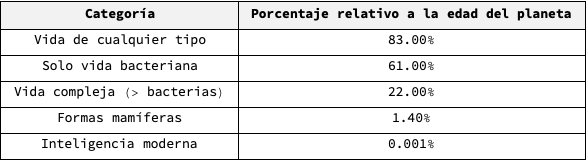

In [49]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];

edadTierra = 4.6 * 10^9;
aparicionVida = 3.8 * 10^9;           
aparicionMulticelular = 1.0 * 10^9;  
aparicionMamiferos = 65 * 10^6;      
aparicionHumanos = 50000;            

porcentajeVida = (aparicionVida / edadTierra) * 100;

porcentajeSoloBacterias = ((aparicionVida - aparicionMulticelular) / edadTierra) * 100;

porcentajeMasCompleja = (aparicionMulticelular / edadTierra) * 100;

porcentajeMamiferos = (aparicionMamiferos / edadTierra) * 100;

porcentajeHumanos = (aparicionHumanos / edadTierra) * 100;

Grid[{
  {Style["Categoría", Bold], Style["Porcentaje relativo a la edad del planeta", Bold]},
  {"Vida de cualquier tipo", Row[{NumberForm[porcentajeVida, {2, 2}], "%"}]},
  {"Solo vida bacteriana", Row[{NumberForm[porcentajeSoloBacterias, {2, 2}], "%"}]},
  {"Vida compleja (> bacterias)", Row[{NumberForm[porcentajeMasCompleja, {2, 2}], "%"}]},
  {"Formas mamíferas", Row[{NumberForm[porcentajeMamiferos, {2, 2}], "%"}]},
  {"Inteligencia moderna", Row[{NumberForm[porcentajeHumanos, {1, 3}], "%"}]}
}, Frame -> All, Background -> {None, {Lighter[Gray, 0.9], None}}, Spacings -> {2, 1}]


# Problema 2

-Graphics-
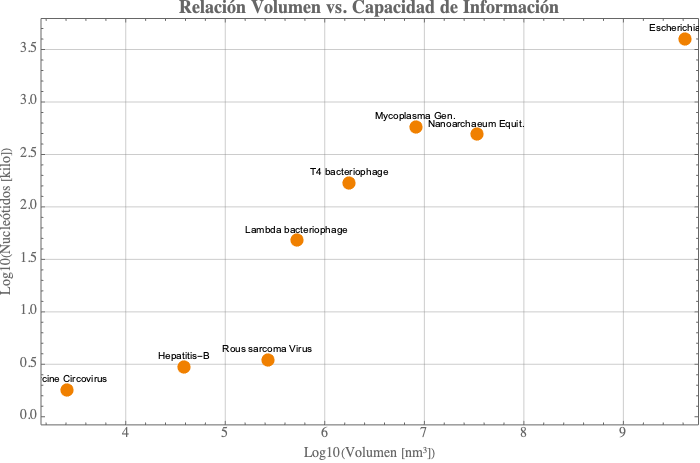

In [40]:
Clear["Global`*"]

ruta = FileNameJoin[{Directory[], "BiologicalSystems.dat"}];
datosRaw = Import[ruta, "Table"];

nombres = datosRaw[[All, 1]];
diametros = datosRaw[[All, 2]];
nucleotidosK = datosRaw[[All, 3]];

volumenes = Table[(4/3) * Pi * (diametros[[i]]/2)^3, {i, Length[diametros]}];
logV = Log10[volumenes];
logN = Log10[nucleotidosK];

puntosGrafica = Table[{logV[[i]], logN[[i]]}, {i, Length[logV]}];

ListPlot[puntosGrafica, 
 PlotStyle -> {Directive[PointSize[0.02], RGBColor[0.94, 0.5, 0]]},
 Frame -> True,
 GridLines -> Automatic,
 PlotTheme -> "Scientific",
 FrameLabel -> {Style["Log10(Volumen [nm³])", 14], Style["Log10(Nucleótidos [kilo])", 14]},
 FrameTicksStyle->Directive[14],
 PlotLabel -> Style["Relación Volumen vs. Capacidad de Información", 18, Bold],
 Epilog -> Table[Inset[Style[nombres[[i]], 10], puntosGrafica[[i]], {0, -1.5}], {i, Length[nombres]}],
 ImageSize -> 700
]

# Problema 3

-Graphics-
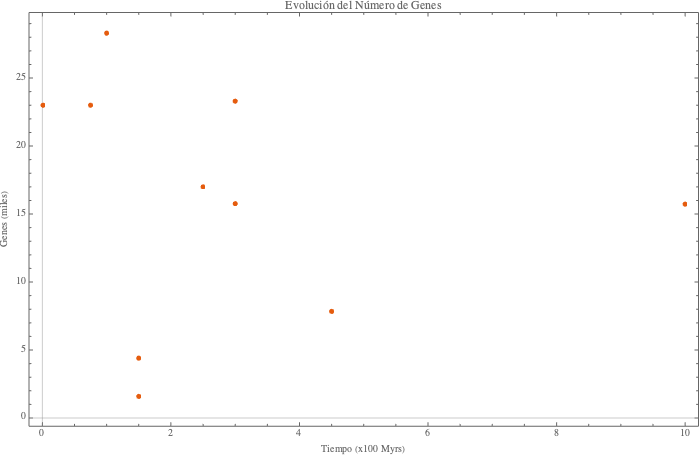

In [101]:
Clear["Global`*"]

(* 1. Importación de datos desde el archivo .dat *)
ruta = FileNameJoin[{Directory[], "NucleotidesEvolution.dat"}];
datos = Import[ruta, "Table"];

(* 
Estructura del archivo:
Col 1: Especie | Col 2: Edad (Myr) | Col 3: Nucleótidos (Millones) | Col 4: Genes
*)

nombres = datos[[All, 1]];
tiempoX = datos[[All, 2]] / 100; (* Unidades de 100 millones de años *)
genesK = datos[[All, 4]] / 1000;  (* Unidades de miles de genes *)
nucleotidosM = datos[[All, 3]];   (* Ya están en millones según el archivo *)

(* 2. PUNTO 1: Gráfica y Tasa de Cambio de Genes *)
graficaGenes = ListPlot[Transpose[{tiempoX, genesK}], 
  PlotLabel -> "Evolución del Número de Genes", 
  FrameLabel -> {"Tiempo (x100 Myrs)", "Genes (miles)"}, 
  PlotMarkers -> Automatic, 
  PlotTheme -> "Scientific",
  ImageSize->700]

-Graphics-
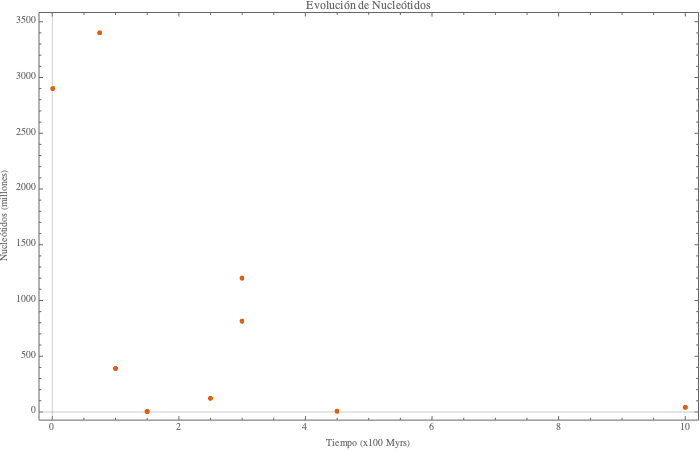

In [88]:
(* Tasa oficial usando Humano y Ameba (Naegleria Gruberi) *)
(* Humano: 23k genes, 0.01 unidades de tiempo | Ameba: 15.7k genes, 10 unidades *)
tasaGenes = (23000 - 15727) / 10; 

(* 3. PUNTO 2: Gráfica y Tasa de Cambio de Nucleótidos *)
graficaNucleotidos = ListPlot[Transpose[{tiempoX, nucleotidosM}], 
  PlotLabel -> "Evolución de Nucleótidos", 
  FrameLabel -> {"Tiempo (x100 Myrs)", "Nucleótidos (millones)"}, 
  PlotMarkers -> Automatic, 
  PlotTheme -> "Scientific",
  ImageSize->700]

In [112]:
(* Tasa oficial usando Ratón y Ameba *)
(* Ratón: 3400M nucleótidos, 0.75 unidades | Ameba: 41M nucleótidos, 10 unidades *)
tasaNucleotidos = (3400 - 41) / (10 - 0.75);

(* 4. PUNTO 3: Predicción para un planeta de 7 Gy *)
(* El planeta es 2400 millones de años más viejo que la Tierra (24 unidades) *)
unidadesExtra = 24; 
prediccionN = 3400 + (370 * unidadesExtra); (* Usando tasa redondeada de 370 *)
prediccionG = 23000 + (700 * unidadesExtra); (* Usando tasa redondeada de 700 *)

In [120]:
Print[Style["\nAnálisis de Evolución Genética (Solución Oficial):", Bold, 14]];
Print["1. Tasa de cambio de genes: ~", Round[tasaGenes], " por cada 100 Myrs."];
Print["2. Tasa de cambio de nucleótidos: ~", Round[tasaNucleotidos], " millones por cada 100 Myrs."];
Print["\n3. Estimación para un planeta de 7 mil millones de años:"];
Print["   - Nucleótidos: ", NumberForm[prediccionN/1000, {3, 1}], " mil millones (12 billion)."];
Print["   - Genes: ", prediccionG];


-Graphics-
graficaNucleotidos

Ana'lisis de Evolucio'n Gene'tica (Solucio'n Oficial):
1. Tasa de cambio de genes: ~Round[tasaGenes] por cada 100 Myrs.
2. Tasa de cambio de nucleo'tidos: ~363 millones por cada 100 Myrs.

3. Estimacio'n para un planeta de 7 mil millones de an~os:
                   307
   - Nucleo'tidos: --- mil millones (12 billion).
                   25
   - Genes: 39800
